# **PHÂN TÍCH: TAI NẠN GIAO THÔNG NEWYORK CITY 2020-2021**

Người thực hiện: Võ Bạch Kim Thịnh

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings

In [ ]:
# Tắt các cảnh báo để output gọn gàng hơn
warnings.filterwarnings('ignore')

# Đặt giao diện cho biểu đồ seaborn
sns.set_theme(style="whitegrid")

# Tải dữ liệu
# Lưu ý: Đảm bảo các file này đã được tải lên môi trường Colab của bạn
df_21_23 = pd.read_csv("NYC_Collisions.csv")
df_2020 = pd.read_csv("NYC Accidents 2020.csv")
data_dict = pd.read_csv("NYC_Collisions_data_dictionary.csv")

print("Tải dữ liệu thành công!")
print(f"Kích thước dữ liệu 2021-2023: {df_21_23.shape}")
print(f"Kích thước dữ liệu 2020: {df_2020.shape}")

Tải dữ liệu thành công!
Kích thước dữ liệu 2021-2023: (238421, 18)
Kích thước dữ liệu 2020: (74881, 29)


Nguồn dữ liệu: NYC Traffic Accidents 2020 (https://mavenanalytics.io/data-playground/nyc-traffic-accidents). Các vụ tai nạn giao thông do Sở Cảnh sát Thành phố New York báo cáo từ tháng 1 đến tháng 8 năm 2020. Mỗi bản ghi đại diện cho một vụ tai nạn riêng lẻ, bao gồm ngày, giờ và địa điểm xảy ra tai nạn (quận, mã bưu chính, tên đường, vĩ độ/kinh độ), các phương tiện và nạn nhân liên quan, và các yếu tố góp phần gây ra tai nạn.

Nguồn dữ liệu: NYC_Collisions.csv (https://app.mavenanalytics.io/datasets?search=NYC+traffic+Accidents). Các vụ tai nạn giao thông do Sở Cảnh sát Thành phố New York báo cáo từ tháng 1 năm 2021 đến tháng 4 năm 2023. Mỗi bản ghi đại diện cho một vụ tai nạn riêng lẻ, bao gồm ngày, giờ và địa điểm xảy ra tai nạn (quận, mã bưu chính, tên đường, vĩ độ/kinh độ), các phương tiện và nạn nhân liên quan, và các yếu tố góp phần gây ra tai nạn.

## TIỀN XỬ LÝ & ĐỒNG NHẤT CẤU TRÚC DỮ LIỆU (DATA HARMONIZATION)

In [ ]:
# 1. Tạo từ điển ánh xạ để đổi tên cột của năm 2020 cho khớp với 2021-2023
rename_dict = {
    'COLLISION_ID': 'Collision ID',
    'CRASH DATE': 'Date',
    'CRASH TIME': 'Time',
    'BOROUGH': 'Borough',
    'ON STREET NAME': 'Street Name',
    'CROSS STREET NAME': 'Cross Street',
    'LATITUDE': 'Latitude',
    'LONGITUDE': 'Longitude',
    'CONTRIBUTING FACTOR VEHICLE 1': 'Contributing Factor',
    'VEHICLE TYPE CODE 1': 'Vehicle Type',
    'NUMBER OF PERSONS INJURED': 'Persons Injured',
    'NUMBER OF PERSONS KILLED': 'Persons Killed',
    'NUMBER OF PEDESTRIANS INJURED': 'Pedestrians Injured',
    'NUMBER OF PEDESTRIANS KILLED': 'Pedestrians Killed',
    'NUMBER OF CYCLIST INJURED': 'Cyclists Injured',
    'NUMBER OF CYCLIST KILLED': 'Cyclists Killed',
    'NUMBER OF MOTORIST INJURED': 'Motorists Injured',
    'NUMBER OF MOTORIST KILLED': 'Motorists Killed'
}

# Áp dụng đổi tên
df_2020_renamed = df_2020.rename(columns=rename_dict)

# 2. Chỉ trích xuất 18 cột có mặt trong tập dữ liệu 2021-2023
target_columns = df_21_23.columns.tolist()

# Lọc dataframe 2020 để chỉ giữ lại các cột khớp nhau
# (Việc này tự động bỏ qua các xe 2,3,4,5, ZIP CODE, LOCATION...)
df_2020_clean = df_2020_renamed[target_columns]

# 3. Chuyển đổi cột 'Date' sang định dạng datetime
df_21_23['Date'] = pd.to_datetime(df_21_23['Date'], errors='coerce')
df_2020_clean['Date'] = pd.to_datetime(df_2020_clean['Date'], errors='coerce')

print("Đồng nhất dữ liệu hoàn tất. Định dạng các cột đã khớp nhau.")

Đồng nhất dữ liệu hoàn tất. Định dạng các cột đã khớp nhau.


In [ ]:
# 1. Nối 2 dataframe theo chiều dọc (Gộp 2020 và 2021-2023)
df_master = pd.concat([df_2020_clean, df_21_23], ignore_index=True)

# 2. Xử lý giá trị bị thiếu (Missing Values)
# Điền 'Unspecified' vào các cột dữ liệu chữ bị thiếu
text_cols = ['Borough', 'Street Name', 'Cross Street', 'Contributing Factor', 'Vehicle Type']
df_master[text_cols] = df_master[text_cols].fillna('Unspecified')

# Loại bỏ các dòng bị thiếu hoặc sai tọa độ (phục vụ vẽ bản đồ)
df_master = df_master.dropna(subset=['Latitude', 'Longitude'])
df_master = df_master[(df_master['Latitude'] != 0) & (df_master['Longitude'] != 0)]

# Xóa khoảng trắng thừa 2 đầu và Viết hoa chữ cái đầu (Title Case)
df_master['Borough'] = df_master['Borough'].astype(str).str.strip().str.title()
df_master['Street Name'] = df_master['Street Name'].astype(str).str.strip().str.title()
df_master['Cross Street'] = df_master['Cross Street'].astype(str).str.strip().str.title()

print("Gộp và chuẩn hóa dữ liệu hoàn tất!")
print(f"Kích thước Master Dataset (2020-2023): {df_master.shape}")
print("Danh sách các Quận (Borough) sau khi làm sạch:", df_master['Borough'].unique())

# Hiển thị 3 dòng đầu để kiểm tra
df_master.head(10)

Gộp và chuẩn hóa dữ liệu hoàn tất!
Kích thước Master Dataset (2020-2023): (284970, 18)
Danh sách các Quận (Borough) sau khi làm sạch: ['Bronx' 'Brooklyn' 'Unspecified' 'Queens' 'Manhattan' 'Staten Island']


,Collision ID,Date,Time,Borough,Street Name,Cross Street,Latitude,Longitude,Contributing Factor,Vehicle Type,Persons Injured,Persons Killed,Pedestrians Injured,Pedestrians Killed,Cyclists Injured,Cyclists Killed,Motorists Injured,Motorists Killed
0,4342908,2020-08-29,15:40:00,Bronx,Pratt Avenue,Strang Avenue,40.892100,-73.833760,Passing Too Closely,Sedan,0.0,0,0,0,0,0,0,0
1,4343555,2020-08-29,21:00:00,Brooklyn,Bushwick Avenue,Palmetto Street,40.690500,-73.919914,Reaction to Uninvolved Vehicle,Sedan,2.0,0,0,0,0,0,2,0
2,4343142,2020-08-29,18:20:00,Unspecified,8 Avenue,Unspecified,40.816500,-73.946556,Backing Unsafely,Station Wagon/Sport Utility Vehicle,1.0,0,1,0,0,0,0,0
3,4343588,2020-08-29,00:00:00,Bronx,Unspecified,Unspecified,40.824720,-73.892960,Unsafe Speed,Station Wagon/Sport Utility Vehicle,0.0,0,0,0,0,0,0,0
4,4342953,2020-08-29,17:10:00,Brooklyn,Unspecified,Unspecified,40.649890,-73.933890,Failure to Yield Right-of-Way,Sedan,0.0,0,0,0,0,0,0,0
5,4342721,2020-08-29,03:29:00,Unspecified,Woodhaven Boulevard,Unspecified,40.682310,-73.844950,Unspecified,Station Wagon/Sport Utility Vehicle,1.0,0,0,0,0,0,1,0
6,4343004,2020-08-29,19:30:00,Bronx,Longfellow Avenue,East 165 Street,40.825226,-73.887780,Unspecified,Station Wagon/Sport Utility Vehicle,0.0,0,0,0,0,0,0,0
7,4343342,2020-08-29,00:00:00,Unspecified,2 Avenue,Unspecified,40.800160,-73.935380,Unsafe Lane Changing,Station Wagon/Sport Utility Vehicle,0.0,0,0,0,0,0,0,0
8,4343030,2020-08-29,19:50:00,Bronx,East 233 Street,Carpenter Avenue,40.894314,-73.860270,Unsafe Speed,Sedan,0.0,0,0,0,0,0,0,0
9,4343040,2020-08-29,09:20:00,Queens,Unspecified,Unspecified,40.706780,-73.908880,Unspecified,Sedan,0.0,0,0,0,0,0,0,0


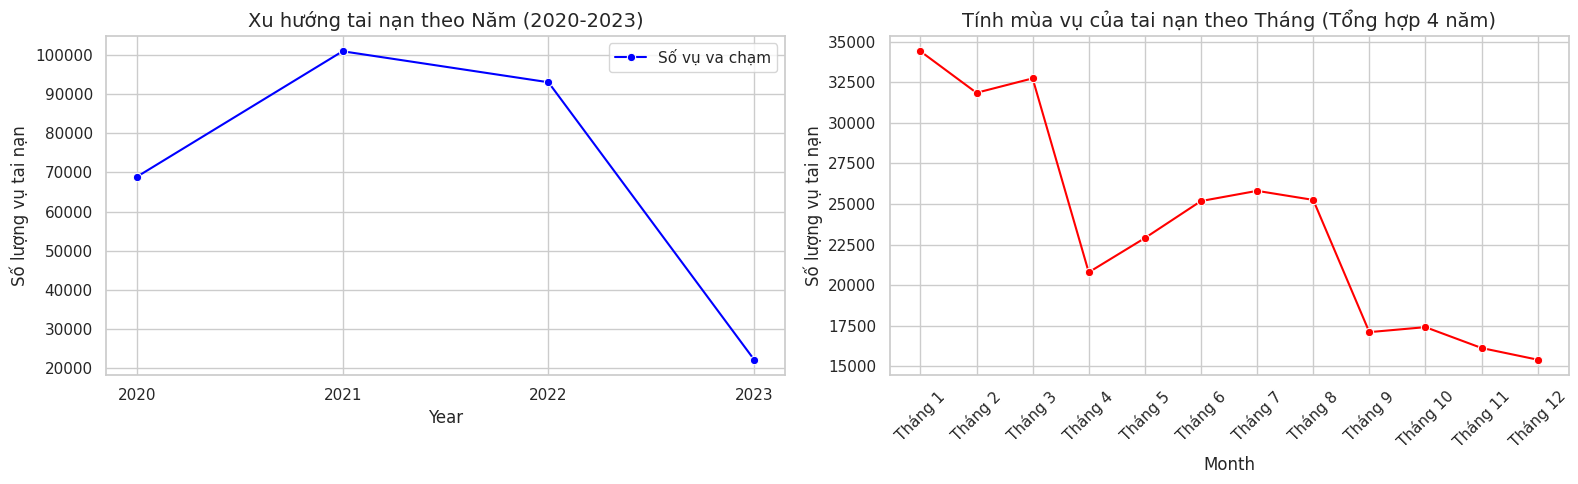

In [ ]:
# Trích xuất Năm và Tháng để tổng hợp
df_master['Year'] = df_master['Date'].dt.year
df_master['Month'] = df_master['Date'].dt.month

# Nhóm theo Năm và Tháng
yearly_stats = df_master.groupby('Year').agg(
    Total_Collisions=('Collision ID', 'count'),
    Total_Injured=('Persons Injured', 'sum'),
    Total_Killed=('Persons Killed', 'sum')
).reset_index()

monthly_stats = df_master.groupby('Month').agg(
    Total_Collisions=('Collision ID', 'count')
).reset_index()

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ 1: Xu hướng theo năm
sns.lineplot(data=yearly_stats, x='Year', y='Total_Collisions', marker='o', ax=axes[0], color='blue', label='Số vụ va chạm')
axes[0].set_title('Xu hướng tai nạn theo Năm (2020-2023)', fontsize=14)
axes[0].set_xticks(yearly_stats['Year'])
axes[0].set_ylabel('Số lượng vụ tai nạn')

# Biểu đồ 2: Tính mùa vụ theo tháng
sns.lineplot(data=monthly_stats, x='Month', y='Total_Collisions', marker='o', ax=axes[1], color='red')
axes[1].set_title('Tính mùa vụ của tai nạn theo Tháng (Tổng hợp 4 năm)', fontsize=14)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Tháng 1', 'Tháng 2', 'Tháng 3', 'Tháng 4', 'Tháng 5', 'Tháng 6', 'Tháng 7', 'Tháng 8', 'Tháng 9', 'Tháng 10', 'Tháng 11', 'Tháng 12'], rotation=45)
axes[1].set_ylabel('Số lượng vụ tai nạn')

plt.tight_layout()
plt.show()

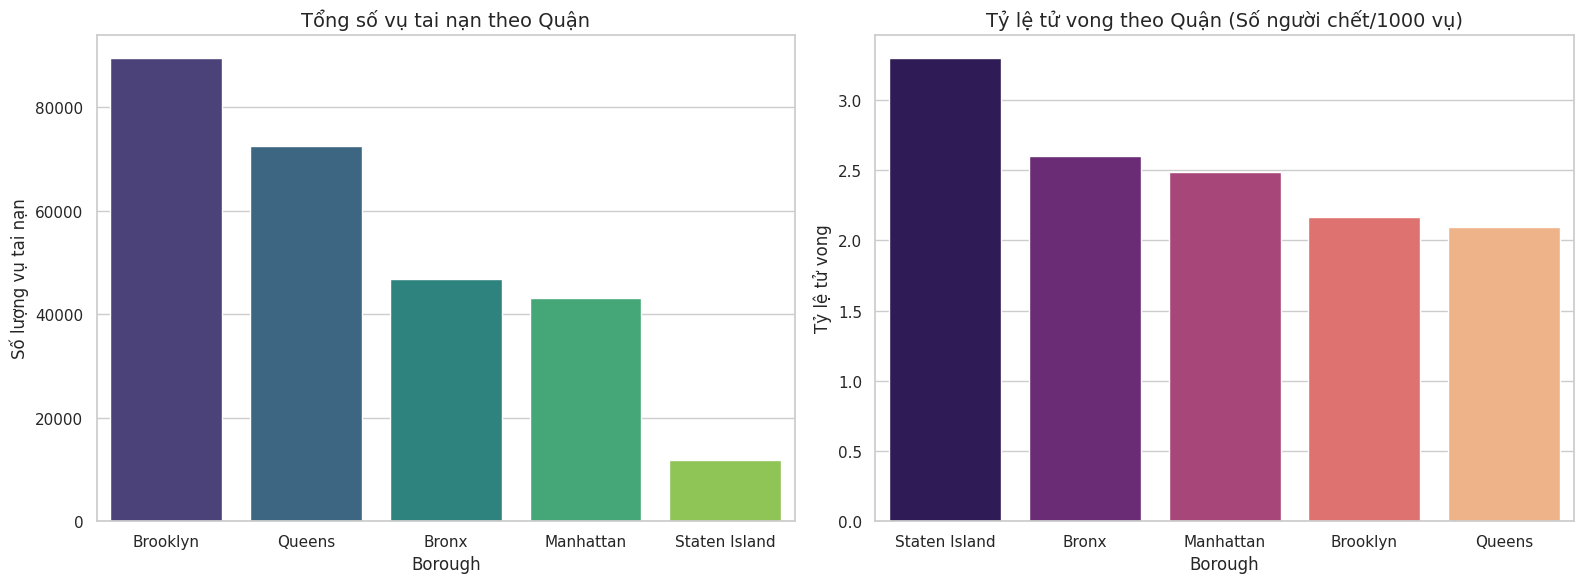

In [ ]:
# Lọc bỏ các quận 'Unspecified' (Không xác định) để xem rõ dữ liệu thực tế
df_boroughs = df_master[df_master['Borough'] != 'Unspecified']

# Nhóm theo Quận (Borough)
borough_stats = df_boroughs.groupby('Borough').agg(
    Total_Collisions=('Collision ID', 'count'),
    Total_Killed=('Persons Killed', 'sum')
).reset_index()

# Tính tỷ lệ tử vong (Số người chết trên 1000 vụ tai nạn)
borough_stats['Mortality_Rate_Per_1000'] = (borough_stats['Total_Killed'] / borough_stats['Total_Collisions']) * 1000
borough_stats = borough_stats.sort_values(by='Total_Collisions', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Tổng số vụ tai nạn theo Quận
sns.barplot(data=borough_stats, x='Borough', y='Total_Collisions', palette='viridis', ax=axes[0])
axes[0].set_title('Tổng số vụ tai nạn theo Quận', fontsize=14)
axes[0].set_ylabel('Số lượng vụ tai nạn')

# Biểu đồ 2: Tỷ lệ tử vong theo Quận
borough_stats = borough_stats.sort_values(by='Mortality_Rate_Per_1000', ascending=False)
sns.barplot(data=borough_stats, x='Borough', y='Mortality_Rate_Per_1000', palette='magma', ax=axes[1])
axes[1].set_title('Tỷ lệ tử vong theo Quận (Số người chết/1000 vụ)', fontsize=14)
axes[1].set_ylabel('Tỷ lệ tử vong')

plt.tight_layout()
plt.show()

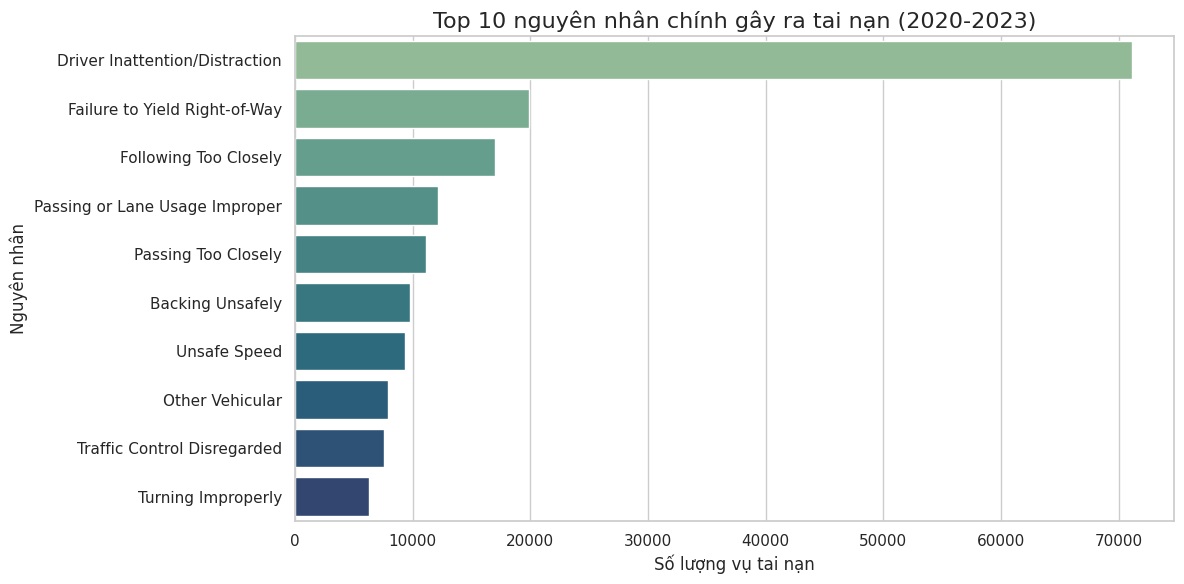

In [ ]:
# Lọc bỏ 'Unspecified' để xem các nguyên nhân cụ thể
df_factors = df_master[df_master['Contributing Factor'] != 'Unspecified']

# Lấy Top 10 nguyên nhân phổ biến nhất
top_factors = df_factors['Contributing Factor'].value_counts().head(10).reset_index()
top_factors.columns = ['Contributing Factor', 'Count']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_factors, y='Contributing Factor', x='Count', palette='crest')

plt.title('Top 10 nguyên nhân chính gây ra tai nạn (2020-2023)', fontsize=16)
plt.xlabel('Số lượng vụ tai nạn')
plt.ylabel('Nguyên nhân')

plt.tight_layout()
plt.show()

In [ ]:
sample_df = df_master.sample(n=100000, random_state=42)

# Tạo bản đồ nền tập trung vào Thành phố New York
# Tọa độ NYC khoảng [40.7128, -74.0060]
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles='CartoDB positron')

# Chuẩn bị dữ liệu tọa độ cho bản đồ nhiệt
heat_data = [[row['Latitude'], row['Longitude']] for index, row in sample_df.iterrows()]

# Thêm lớp Bản đồ nhiệt (HeatMap)
HeatMap(heat_data, radius=10, blur=15, max_zoom=1).add_to(nyc_map)

# Hiển thị bản đồ (Trong Colab, chỉ cần gọi tên biến ở cuối dòng)
nyc_map

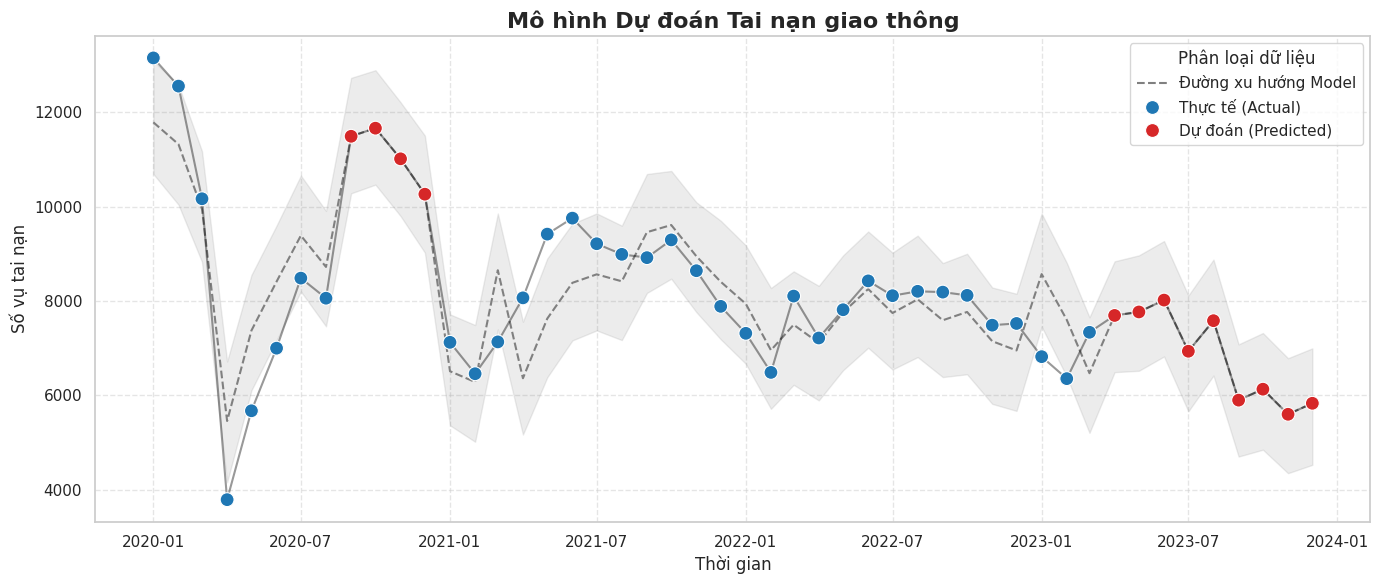

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

# 1. TỔNG HỢP DỮ LIỆU THEO THÁNG TỪ df_master
monthly_data = df_master.groupby(df_master['Date'].dt.to_period('M')).agg(
    Total_Collisions=('Collision ID', 'count')
).reset_index()
monthly_data['Date'] = monthly_data['Date'].dt.to_timestamp()

# 2. TẠO KHUNG THỜI GIAN HOÀN CHỈNH (4 NĂM)
full_dates = pd.DataFrame({'Date': pd.date_range(start='2020-01-01', end='2023-12-01', freq='MS')})
df_full = pd.merge(full_dates, monthly_data, on='Date', how='left')

threshold = 3000
df_full.loc[df_full['Total_Collisions'] < threshold, 'Total_Collisions'] = np.nan

# 3. CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH PROPHET
train_df = df_full.dropna().rename(columns={'Date': 'ds', 'Total_Collisions': 'y'})

# 4. TẠO VÀ TINH CHỈNH MÔ HÌNH (FINE-TUNING)
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.15
)
model.add_country_holidays(country_name='US')
model.fit(train_df)

# 5. DỰ ĐOÁN & ĐIỀN DỮ LIỆU KHUYẾT
future = df_full[['Date']].rename(columns={'Date': 'ds'})
forecast = model.predict(future)

df_full['Predicted_Collisions'] = forecast['yhat'].round()
df_full['Lower_Bound'] = forecast['yhat_lower']
df_full['Upper_Bound'] = forecast['yhat_upper']

# Tạo cột Final: Nếu có dữ liệu thực tế (đã qua lọc lỗi) thì dùng, nếu thiếu thì dùng Dự đoán
df_full['Final_Collisions'] = df_full['Total_Collisions'].fillna(df_full['Predicted_Collisions'])
df_full['Data_Type'] = np.where(df_full['Total_Collisions'].isnull(), 'Dự đoán (Predicted)', 'Thực tế (Actual)')

# 6. TRỰC QUAN HÓA KẾT QUẢ DỰ ĐOÁN
plt.figure(figsize=(14, 6))

# Vẽ đường xu hướng mô hình và khoảng tin cậy
sns.lineplot(data=df_full, x='Date', y='Predicted_Collisions', color='grey', linestyle='--', label='Đường xu hướng Model')
plt.fill_between(df_full['Date'], df_full['Lower_Bound'], df_full['Upper_Bound'], color='grey', alpha=0.15)

# Vẽ Scatter plot phân biệt Thực tế và Dự đoán
sns.scatterplot(data=df_full, x='Date', y='Final_Collisions', hue='Data_Type',
                palette={'Thực tế (Actual)': '#1f77b4', 'Dự đoán (Predicted)': '#d62728'},
                s=100, zorder=5)
sns.lineplot(data=df_full, x='Date', y='Final_Collisions', color='black', alpha=0.4, zorder=4)

plt.title('Mô hình Dự đoán Tai nạn giao thông', fontsize=16, fontweight='bold')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Số vụ tai nạn', fontsize=12)
plt.legend(title='Phân loại dữ liệu')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

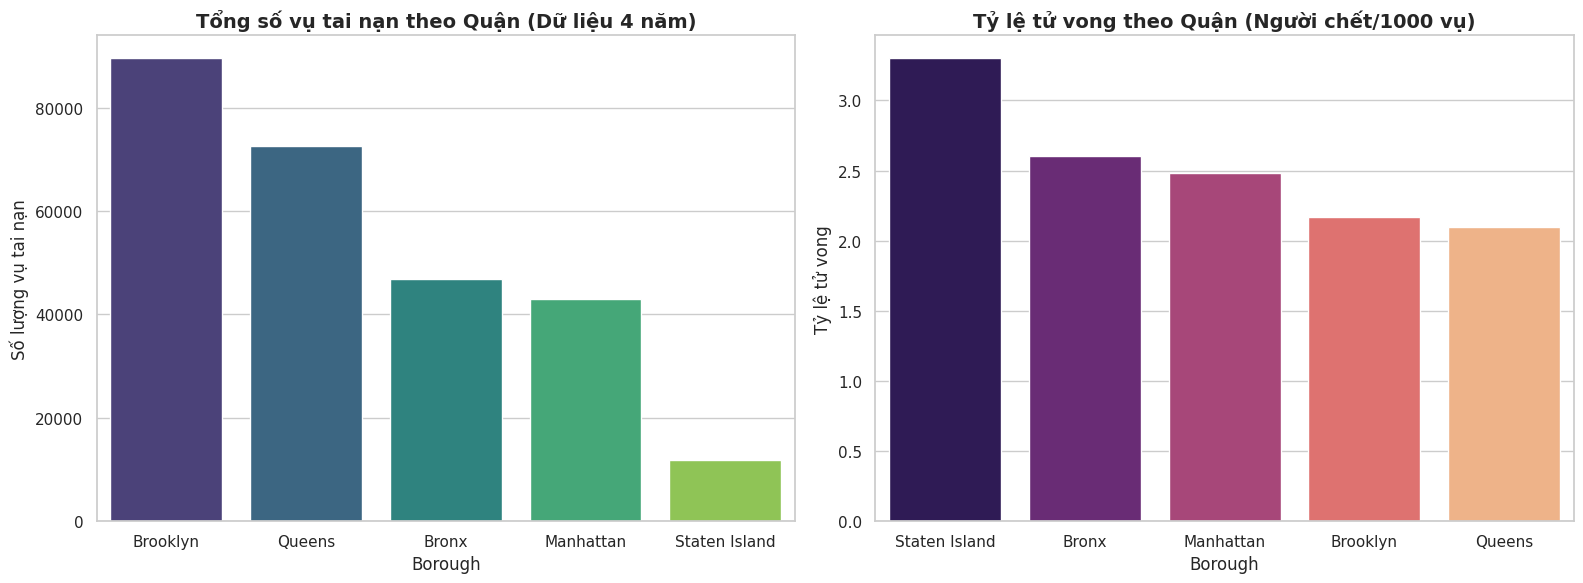

In [ ]:
# 1. Tính toán lại thống kê theo Quận dựa trên dữ liệu Master đã được làm sạch
# Lọc bỏ các quận 'Unspecified'
df_boroughs_final = df_master[df_master['Borough'] != 'Unspecified']

# Nhóm theo Quận để tính tổng số vụ và số người chết
borough_summary = df_boroughs_final.groupby('Borough').agg(
    Total_Collisions=('Collision ID', 'count'),
    Total_Killed=('Persons Killed', 'sum')
).reset_index()

# 2. Tính tỷ lệ tử vong (Số người chết trên 1000 vụ tai nạn)
borough_summary['Mortality_Rate_Per_1000'] = (borough_summary['Total_Killed'] / borough_summary['Total_Collisions']) * 1000
borough_summary = borough_summary.sort_values(by='Total_Collisions', ascending=False)

# 3. Trực quan hóa so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Tổng số vụ tai nạn theo Quận (Dữ liệu toàn diện 2020-2023)
sns.barplot(data=borough_summary, x='Borough', y='Total_Collisions', palette='viridis', ax=axes[0])
axes[0].set_title('Tổng số vụ tai nạn theo Quận (Dữ liệu 4 năm)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Số lượng vụ tai nạn')

# Biểu đồ 2: Tỷ lệ tử vong theo Quận
borough_summary_sorted = borough_summary.sort_values(by='Mortality_Rate_Per_1000', ascending=False)
sns.barplot(data=borough_summary_sorted, x='Borough', y='Mortality_Rate_Per_1000', palette='magma', ax=axes[1])
axes[1].set_title('Tỷ lệ tử vong theo Quận (Người chết/1000 vụ)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Tỷ lệ tử vong')

plt.tight_layout()
plt.show()

In [ ]:
# Hiển thị bảng số liệu chi tiết
print("--- THỐNG KÊ CHI TIẾT THEO QUẬN (2020-2023) ---")
display(borough_summary_sorted.style.background_gradient(cmap='Reds', subset=['Mortality_Rate_Per_1000']))

--- THỐNG KÊ CHI TIẾT THEO QUẬN (2020-2023) ---


,Borough,Total_Collisions,Total_Killed,Mortality_Rate_Per_1000
4,Staten Island,11821,39,3.299213
0,Bronx,46842,122,2.604500
2,Manhattan,43054,107,2.485251
1,Brooklyn,89513,194,2.167283
3,Queens,72562,152,2.094760
